<a href="https://colab.research.google.com/github/Abraham-13M/teachable-machine-optativa/blob/main/practica_1_teachable_machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Práctica 1 - Teachable Machine

**Alumno:** Abraham Galdón Fernández
**Asignatura:** Optativa
**Curso:** 2º DAW

## Clasificador de imágenes con Teachable Machine

En esta práctica se ha creado un modelo de clasificación de imágenes mediante
Teachable Machine y posteriormente se ha integrado en una aplicación web
utilizando HTML, CSS, JavaScript y TensorFlow.js.

## 1. Objetivo de la práctica

El objetivo de esta práctica es crear y entrenar un modelo de inteligencia
artificial capaz de clasificar diferentes objetos a partir de imágenes.

Las clases utilizadas en el modelo son:

- Botella
- Papel
- Funda de gafas

Después de entrenar el modelo, se ha integrado en una aplicación web y se han
realizado diferentes mejoras sobre la versión inicial.

## 2. Creación y entrenamiento del modelo

Para crear el modelo se utilizó Teachable Machine en modo proyecto de imágenes.

Se crearon tres clases y se añadieron diferentes imágenes de entrenamiento para
cada una. Una vez recopiladas las muestras se entrenó el modelo para que pudiera
distinguir entre los diferentes objetos.

Después del entrenamiento se comprobó el funcionamiento del modelo utilizando
la vista previa proporcionada por Teachable Machine.
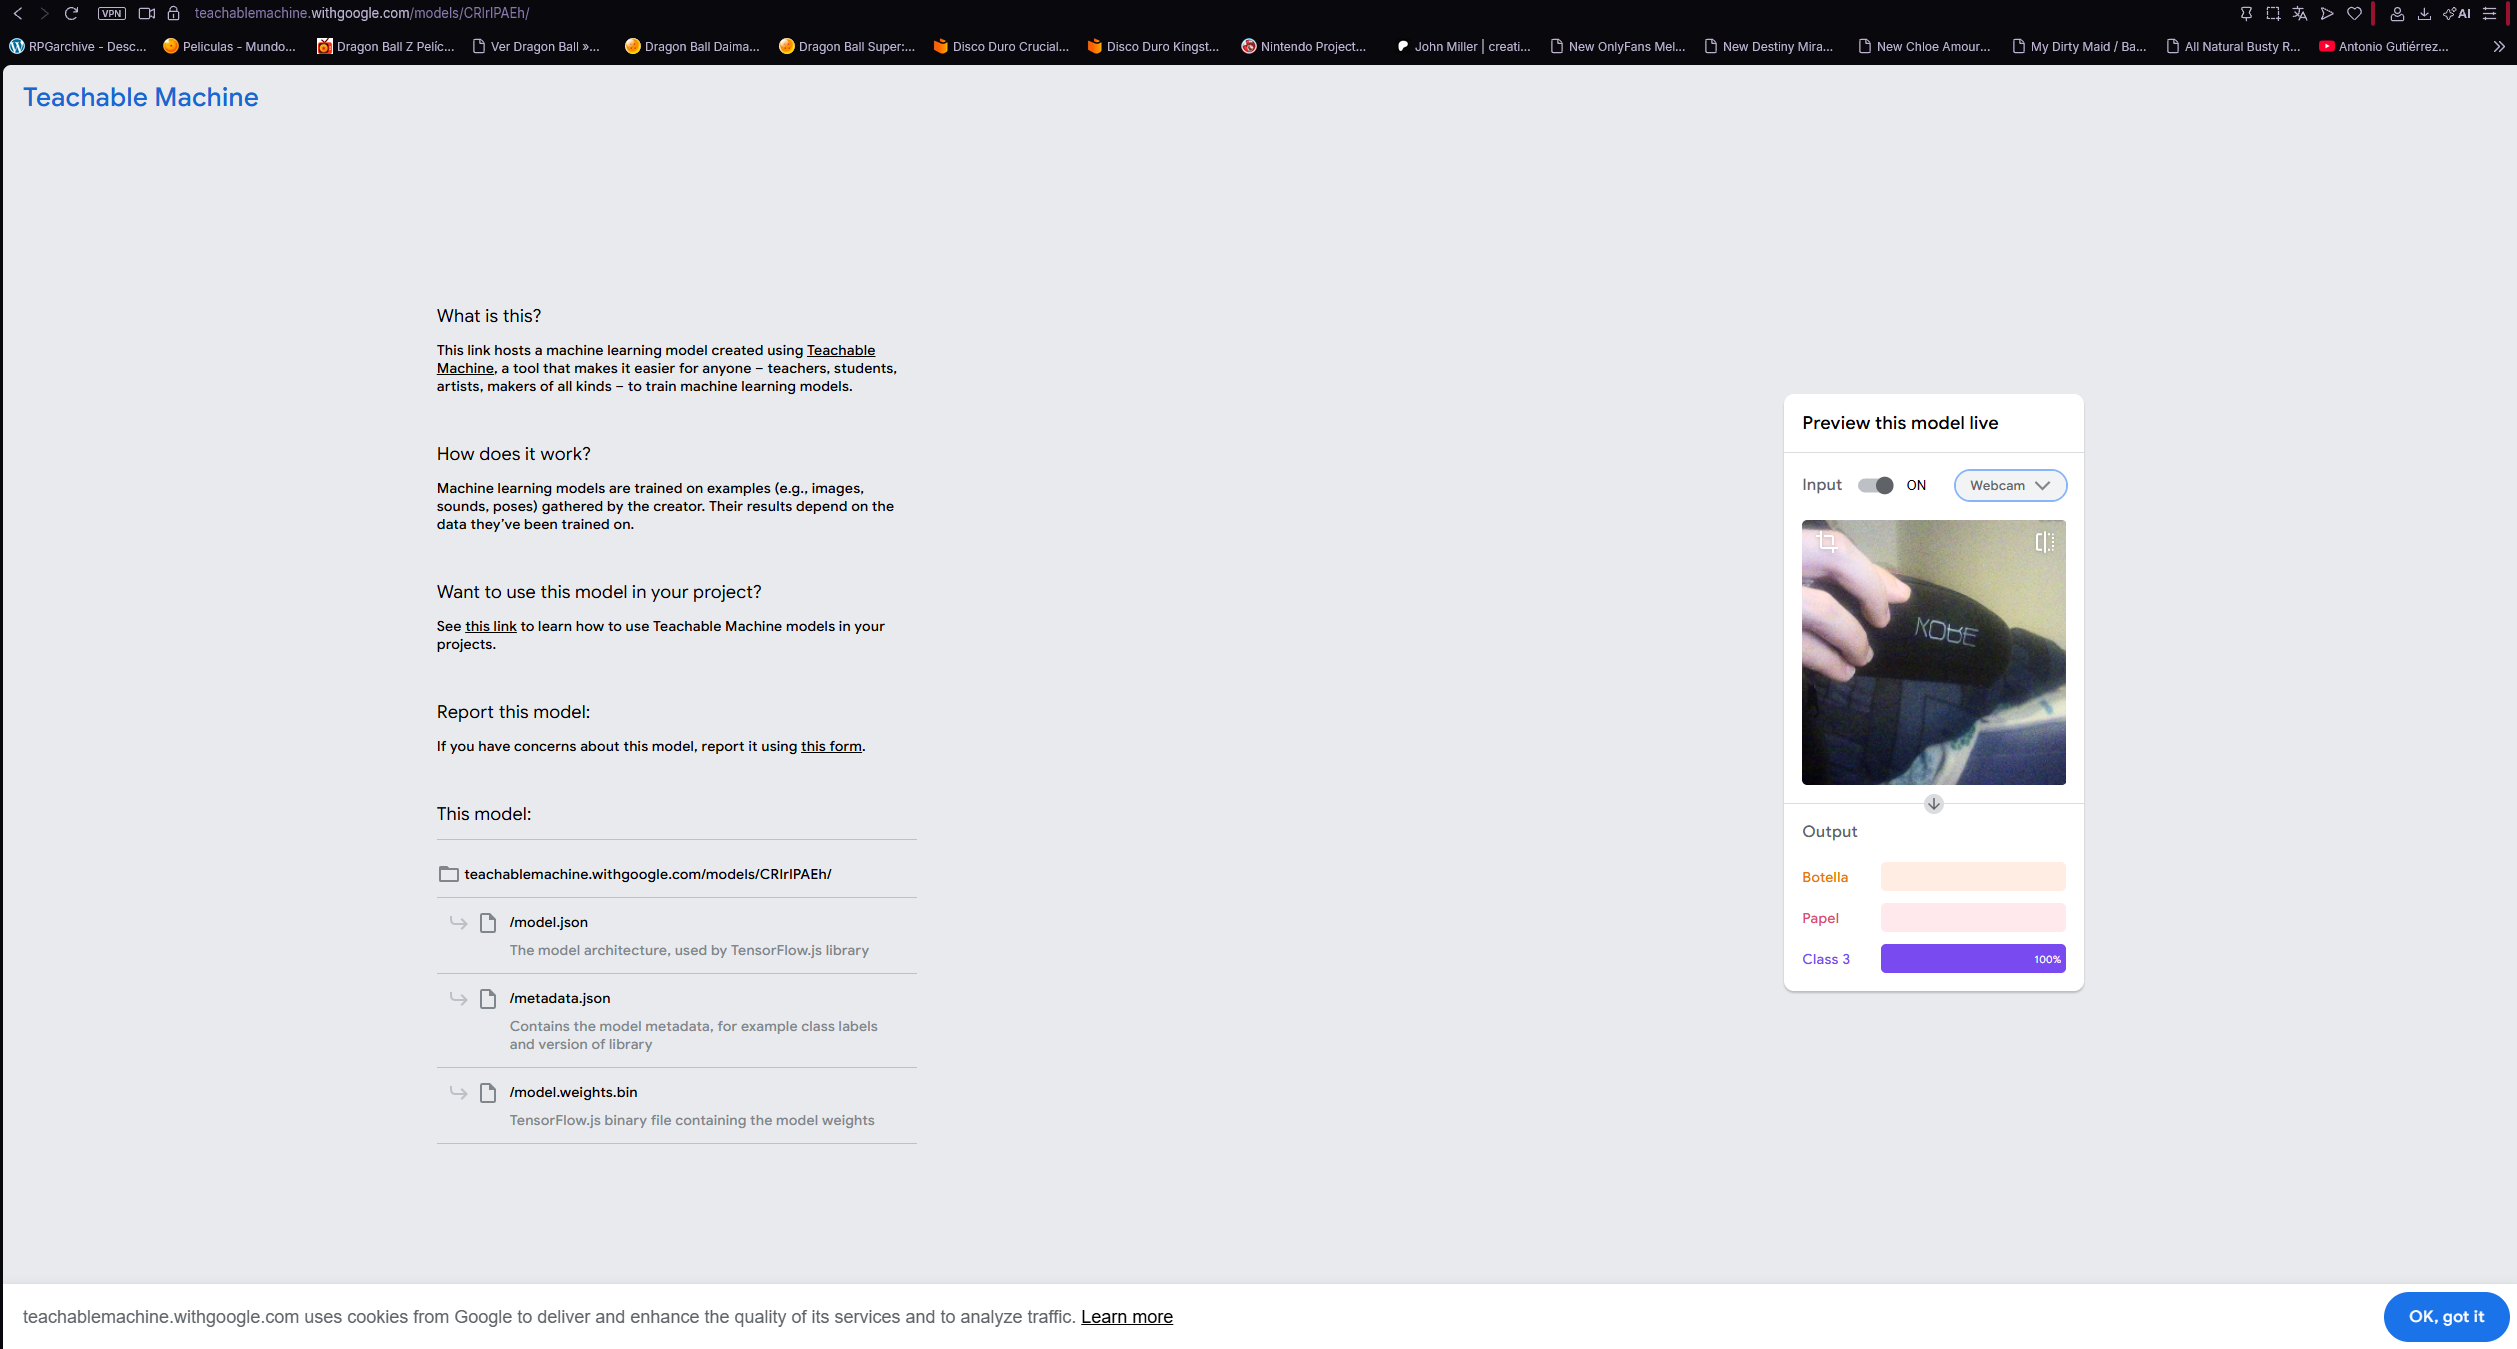

## 3. Exportación del modelo

Una vez entrenado, el modelo se exportó para TensorFlow.js para poder utilizarlo
desde JavaScript en una aplicación web.

Los archivos utilizados son:

- model.json
- metadata.json
- model.weights.bin

También se exportó el modelo en formato TensorFlow para conservarlo y poder
utilizarlo posteriormente en otras prácticas.
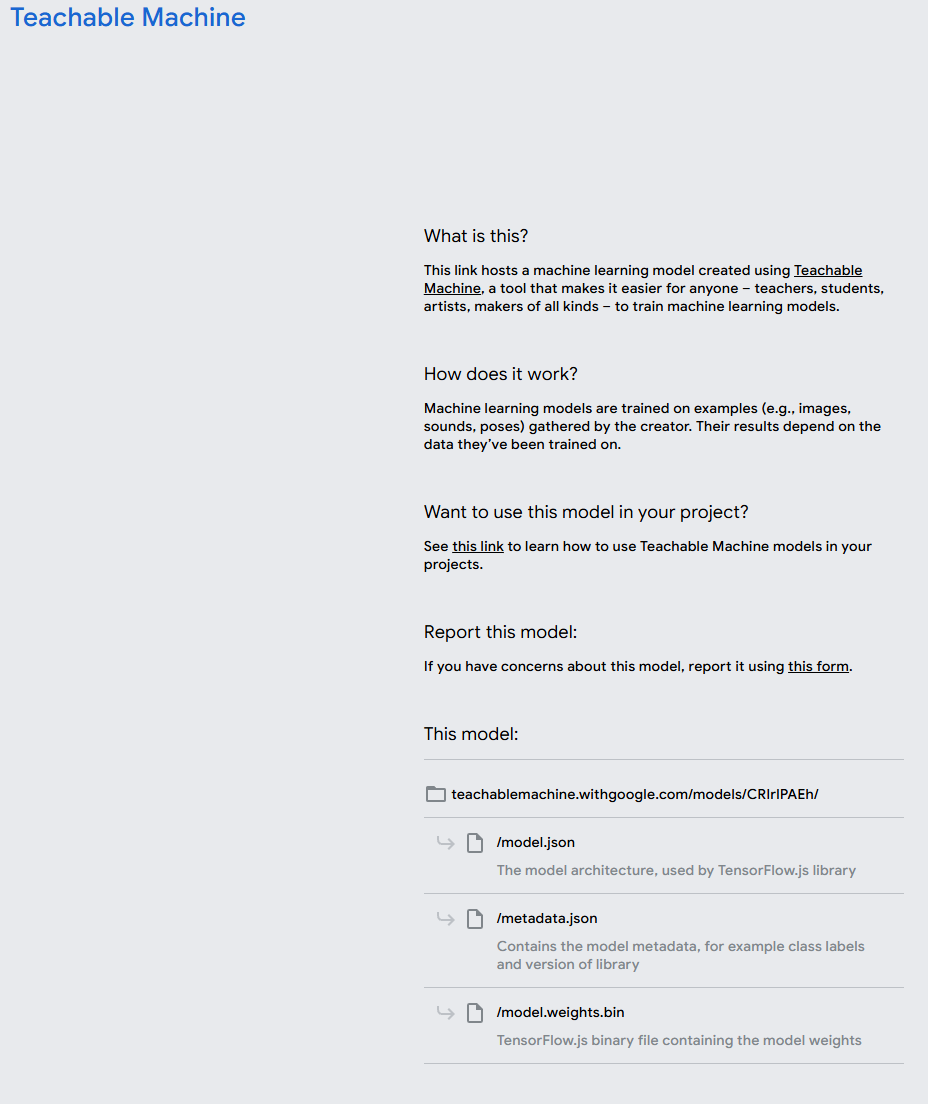

## 4. Estructura de la aplicación

Para utilizar el modelo desde una página web se creó una aplicación con la siguiente estructura:

- `index.html`: contiene la estructura de la página.
- `styles.css`: contiene los estilos y el diseño responsive.
- `app.js`: contiene la lógica de la aplicación.
- `modelo/`: contiene los archivos exportados desde Teachable Machine.
    - `model.json`
    - `metadata.json`
    - `model.weights.bin`

La estructura final del proyecto es:

clasificador/
- index.html
- styles.css
- app.js
- modelo/
  - model.json
  - metadata.json
  - model.weights.bin

## 5. Primera versión de la aplicación

En primer lugar se creó una versión sencilla de la aplicación para comprobar
que el modelo funcionaba correctamente.

Esta primera versión permitía activar la webcam y mostraba el porcentaje de
probabilidad obtenido para cada una de las clases.

Una vez comprobado que el modelo funcionaba correctamente se realizaron las
mejoras solicitadas en la práctica.
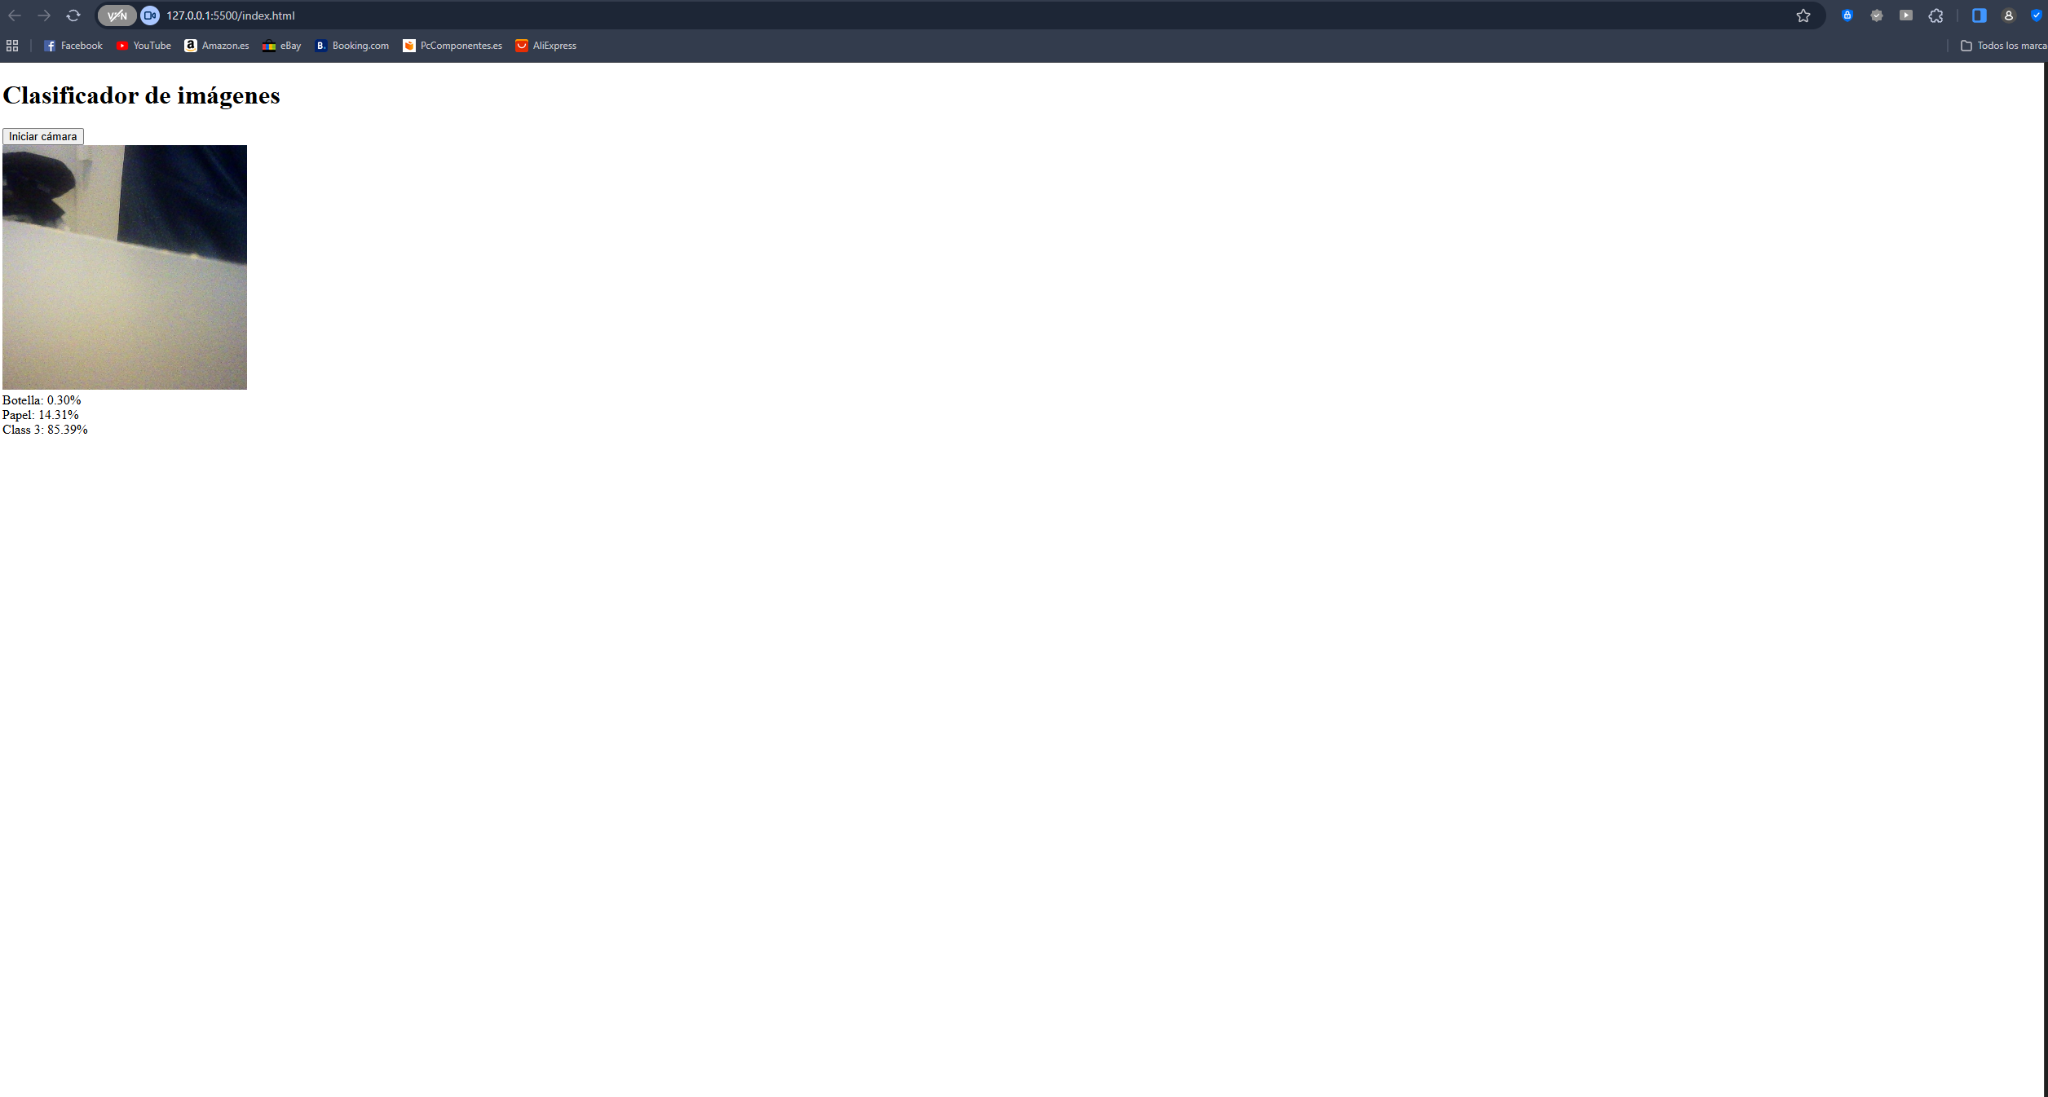

## 6. Código HTML

El archivo `index.html` contiene la estructura principal de la aplicación.

Se han creado diferentes secciones para la webcam, los controles, los resultados,
la subida de imágenes y el historial.

```html
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">

    <title>Clasificador de imágenes</title>

    <link rel="stylesheet" href="styles.css">

    <script src="https://cdn.jsdelivr.net/npm/@tensorflow/tfjs@1.3.1/dist/tf.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/@teachablemachine/image@0.8/dist/teachablemachine-image.min.js"></script>
</head>

<body>

    <main class="contenedor">

        <header>
            <h1>Clasificador de objetos</h1>
            <p>
                Modelo creado con Teachable Machine para reconocer
                botellas, papel y fundas de gafas.
            </p>
        </header>

        <section class="tarjeta">

            <h2>Clasificación con cámara</h2>

            <div id="webcam-container" class="camara">
                <p id="mensaje-camara">
                    Pulsa "Iniciar" para activar la cámara
                </p>
            </div>

            <div class="botones">
                <button id="btn-iniciar" onclick="iniciarCamara()">
                    Iniciar
                </button>

                <button id="btn-parar" onclick="pararCamara()" disabled>
                    Parar
                </button>
            </div>

        </section>


        <section class="tarjeta">

            <h2>Coincidencia mínima</h2>

            <div class="umbral">
                <input
                    type="range"
                    id="umbral"
                    min="0"
                    max="100"
                    value="70"
                    oninput="actualizarUmbral()"
                >

                <span id="valor-umbral">70%</span>
            </div>

            <p class="texto-ayuda">
                Solo se considerará una coincidencia cuando el resultado
                supere este porcentaje.
            </p>

        </section>


        <section class="tarjeta">

            <h2>Resultado</h2>

            <div id="mensaje-resultado" class="mensaje">
                Esperando una imagen...
            </div>

            <div id="label-container"></div>

        </section>


        <section class="tarjeta">

            <h2>Clasificar una imagen</h2>

            <input
                type="file"
                id="imagen-input"
                accept="image/*"
                onchange="cargarImagen(event)"
            >

            <div class="imagen-subida">
                <img id="imagen-preview" alt="">
            </div>

        </section>


        <section class="tarjeta">

            <div class="titulo-historial">
                <h2>Historial de resultados</h2>

                <button
                    class="btn-borrar"
                    onclick="borrarHistorial()"
                >
                    Borrar historial
                </button>
            </div>

            <div id="historial">
                <p id="historial-vacio">
                    Todavía no hay resultados.
                </p>
            </div>

        </section>

    </main>

    <script src="app.js"></script>

</body>
</html>
```

## 7. Diseño de la aplicación

El archivo `styles.css` se utiliza para mejorar la apariencia de la aplicación.

Se han utilizado tarjetas, botones, barras de progreso, separación entre
elementos y diferentes estilos para facilitar la visualización de los resultados.

Además, mediante media queries se ha hecho que la página sea responsive y
pueda adaptarse a dispositivos con diferentes tamaños de pantalla.

```css
* {
    box-sizing: border-box;
    margin: 0;
    padding: 0;
}

body {
    font-family: Arial, Helvetica, sans-serif;
    background: #f2f5f9;
    color: #1f2937;
    min-height: 100vh;
}

.contenedor {
    width: 90%;
    max-width: 900px;
    margin: 0 auto;
    padding: 40px 0;
}

header {
    text-align: center;
    margin-bottom: 30px;
}

header h1 {
    font-size: 2.5rem;
    margin-bottom: 10px;
}

header p {
    color: #64748b;
    line-height: 1.5;
}

.tarjeta {
    background: white;
    padding: 25px;
    margin-bottom: 25px;
    border-radius: 15px;
    box-shadow: 0 4px 15px rgba(0, 0, 0, 0.08);
}

.tarjeta h2 {
    margin-bottom: 20px;
}

.camara {
    min-height: 300px;
    background: #e5e7eb;
    border-radius: 12px;
    display: flex;
    justify-content: center;
    align-items: center;
    overflow: hidden;
}

.camara canvas {
    display: block;
    max-width: 100%;
    height: auto;
}

#mensaje-camara {
    color: #64748b;
}

.botones {
    display: flex;
    justify-content: center;
    gap: 15px;
    margin-top: 20px;
}

button {
    border: none;
    padding: 12px 25px;
    border-radius: 8px;
    font-size: 1rem;
    cursor: pointer;
    background: #2563eb;
    color: white;
}

button:hover {
    opacity: 0.9;
}

button:disabled {
    background: #94a3b8;
    cursor: not-allowed;
}

#btn-parar {
    background: #dc2626;
}

.umbral {
    display: flex;
    align-items: center;
    gap: 20px;
}

.umbral input {
    width: 100%;
}

#valor-umbral {
    min-width: 55px;
    font-weight: bold;
    font-size: 1.1rem;
}

.texto-ayuda {
    color: #64748b;
    margin-top: 10px;
}

.mensaje {
    padding: 15px;
    background: #f1f5f9;
    border-radius: 10px;
    margin-bottom: 20px;
    font-weight: bold;
    text-align: center;
}

.resultado {
    margin-bottom: 15px;
}

.resultado-superior {
    display: flex;
    justify-content: space-between;
    margin-bottom: 5px;
}

.barra {
    width: 100%;
    height: 15px;
    background: #e5e7eb;
    border-radius: 20px;
    overflow: hidden;
}

.barra-interior {
    height: 100%;
    background: #2563eb;
    transition: width 0.3s ease;
}

#imagen-input {
    margin-bottom: 20px;
}

.imagen-subida {
    text-align: center;
}

#imagen-preview {
    display: none;
    max-width: 100%;
    max-height: 350px;
    border-radius: 12px;
}

.titulo-historial {
    display: flex;
    justify-content: space-between;
    align-items: center;
    gap: 15px;
    margin-bottom: 20px;
}

.titulo-historial h2 {
    margin: 0;
}

.btn-borrar {
    background: #475569;
    padding: 10px 15px;
}

.elemento-historial {
    padding: 12px;
    border-bottom: 1px solid #e5e7eb;
}

.elemento-historial:last-child {
    border-bottom: none;
}

.fecha {
    color: #64748b;
    font-size: 0.85rem;
}

#historial-vacio {
    color: #64748b;
}


/* RESPONSIVE */

@media (max-width: 600px) {

    .contenedor {
        width: 94%;
        padding: 20px 0;
    }

    header h1 {
        font-size: 1.8rem;
    }

    .tarjeta {
        padding: 18px;
    }

    .botones {
        flex-direction: column;
    }

    .botones button {
        width: 100%;
    }

    .titulo-historial {
        flex-direction: column;
        align-items: stretch;
    }

    .btn-borrar {
        width: 100%;
    }

    .camara {
        min-height: 220px;
    }
}
```

## 8. Funcionamiento de JavaScript

El archivo `app.js` contiene la lógica principal de la aplicación.

JavaScript se encarga de cargar el modelo de Teachable Machine, controlar la
webcam, realizar las predicciones, comprobar el porcentaje mínimo de
coincidencia, gestionar el historial y permitir la clasificación de imágenes
subidas desde el ordenador.

```javascript
const URL = "./modelo/";

let model;
let webcam;
let maxPredictions;

let ejecutando = false;
let animationId = null;

let ultimaClaseGuardada = "";


/*
    Carga el modelo de Teachable Machine
*/
async function cargarModelo() {

    if (model) {
        return;
    }

    const modelURL = URL + "model.json";
    const metadataURL = URL + "metadata.json";

    model = await tmImage.load(modelURL, metadataURL);

    maxPredictions = model.getTotalClasses();
}


/*
    Iniciar cámara
*/
async function iniciarCamara() {

    if (ejecutando) {
        return;
    }

    try {

        await cargarModelo();

        const contenedor =
            document.getElementById("webcam-container");

        contenedor.innerHTML = "";

        webcam = new tmImage.Webcam(
            300,
            300,
            true
        );

        await webcam.setup();
        await webcam.play();

        contenedor.appendChild(webcam.canvas);

        ejecutando = true;

        document.getElementById("btn-iniciar").disabled = true;
        document.getElementById("btn-parar").disabled = false;

        loop();

    } catch (error) {

        document.getElementById("mensaje-resultado").innerHTML =
            "No se ha podido iniciar la cámara.";

        console.error(error);
    }
}


/*
    Bucle de la webcam
*/
async function loop() {

    if (!ejecutando) {
        return;
    }

    webcam.update();

    await predecir(webcam.canvas, false);

    animationId = window.requestAnimationFrame(loop);
}


/*
    Parar cámara
*/
function pararCamara() {

    ejecutando = false;

    if (animationId) {
        window.cancelAnimationFrame(animationId);
    }

    if (webcam) {
        webcam.stop();
    }

    document.getElementById("webcam-container").innerHTML =
        '<p id="mensaje-camara">Cámara detenida</p>';

    document.getElementById("btn-iniciar").disabled = false;
    document.getElementById("btn-parar").disabled = true;

    document.getElementById("mensaje-resultado").innerHTML =
        "Clasificación detenida.";
}


/*
    Realizar predicción
*/
async function predecir(imagen, guardarSiempre) {

    await cargarModelo();

    const prediction = await model.predict(imagen);

    mostrarPredicciones(prediction);

    let mejorResultado = prediction[0];

    for (let i = 1; i < prediction.length; i++) {

        if (
            prediction[i].probability >
            mejorResultado.probability
        ) {
            mejorResultado = prediction[i];
        }
    }

    const porcentaje =
        mejorResultado.probability * 100;

    const minimo =
        Number(document.getElementById("umbral").value);

    const nombre =
        obtenerNombre(mejorResultado.className);


    if (porcentaje >= minimo) {

        document.getElementById("mensaje-resultado").innerHTML =
            "Se ha detectado <strong>" +
            nombre +
            "</strong> con una confianza del <strong>" +
            porcentaje.toFixed(2) +
            "%</strong>.";

        /*
            En webcam solo guardamos cuando cambia
            el objeto detectado para no llenar el historial.
        */
        if (
            guardarSiempre ||
            ultimaClaseGuardada !== nombre
        ) {

            guardarHistorial(
                nombre,
                porcentaje
            );

            ultimaClaseGuardada = nombre;
        }

    } else {

        document.getElementById("mensaje-resultado").innerHTML =
            "No hay suficiente coincidencia. " +
            "El resultado más alto es " +
            nombre +
            " con " +
            porcentaje.toFixed(2) +
            "%.";
    }
}


/*
    Mostrar porcentajes
*/
function mostrarPredicciones(prediction) {

    const contenedor =
        document.getElementById("label-container");

    contenedor.innerHTML = "";

    for (let i = 0; i < prediction.length; i++) {

        const nombre =
            obtenerNombre(prediction[i].className);

        const porcentaje =
            prediction[i].probability * 100;

        const resultado =
            document.createElement("div");

        resultado.className = "resultado";

        resultado.innerHTML = `
            <div class="resultado-superior">

                <span>${nombre}</span>

                <span>
                    ${porcentaje.toFixed(2)}%
                </span>

            </div>

            <div class="barra">

                <div
                    class="barra-interior"
                    style="width: ${porcentaje}%">
                </div>

            </div>
        `;

        contenedor.appendChild(resultado);
    }
}


/*
    Cambiamos Class 3 por el nombre real
*/
function obtenerNombre(nombre) {

    if (nombre === "Class 3") {
        return "Funda de gafas";
    }

    return nombre;
}


/*
    Actualizar porcentaje mínimo
*/
function actualizarUmbral() {

    const valor =
        document.getElementById("umbral").value;

    document.getElementById("valor-umbral").innerHTML =
        valor + "%";
}


/*
    Subir y clasificar una imagen
*/
async function cargarImagen(event) {

    const archivo = event.target.files[0];

    if (!archivo) {
        return;
    }

    await cargarModelo();

    const imagen =
        document.getElementById("imagen-preview");

    const lector = new FileReader();

    lector.onload = function(e) {

        imagen.src = e.target.result;

        imagen.style.display = "inline-block";

        imagen.onload = async function() {

            await predecir(
                imagen,
                true
            );
        };
    };

    lector.readAsDataURL(archivo);
}


/*
    Guardar historial
*/
function guardarHistorial(nombre, porcentaje) {

    const historial =
        document.getElementById("historial");

    const vacio =
        document.getElementById("historial-vacio");

    if (vacio) {
        vacio.remove();
    }

    const fecha =
        new Date().toLocaleString();

    const elemento =
        document.createElement("div");

    elemento.className =
        "elemento-historial";

    elemento.innerHTML = `
        <strong>${nombre}</strong>
        - ${porcentaje.toFixed(2)}%

        <br>

        <span class="fecha">
            ${fecha}
        </span>
    `;

    historial.prepend(elemento);
}


/*
    Borrar historial
*/
function borrarHistorial() {

    const historial =
        document.getElementById("historial");

    historial.innerHTML = `
        <p id="historial-vacio">
            Todavía no hay resultados.
        </p>
    `;

    ultimaClaseGuardada = "";
}
```

## 9. Mejoras realizadas

### 9.1 Mejora del diseño

Se ha modificado el diseño inicial de la aplicación mediante CSS para conseguir una interfaz más clara y organizada.

### 9.2 Diseño responsive

Se han añadido media queries para que la aplicación pueda adaptarse a pantallas
de diferentes tamaños.

### 9.3 Botones de inicio y parada

Se han añadido dos botones. El botón "Iniciar" activa la webcam y comienza la
clasificación, mientras que el botón "Parar" detiene la cámara.

### 9.4 Mensaje personalizado

La aplicación muestra el objeto que se ha detectado junto al porcentaje de
confianza obtenido.

### 9.5 Coincidencia mínima

Se ha añadido un control deslizante que permite establecer el porcentaje mínimo
necesario para considerar válida una coincidencia. El valor inicial es del 70 %.

### 9.6 Historial de resultados

Las clasificaciones válidas se muestran en un historial junto al porcentaje
obtenido y la fecha y hora.

También se ha añadido un botón que permite borrar el historial.

### 9.7 Subida de imágenes

Además de utilizar la webcam, la aplicación permite seleccionar una imagen
almacenada en el ordenador y clasificarla utilizando el mismo modelo.
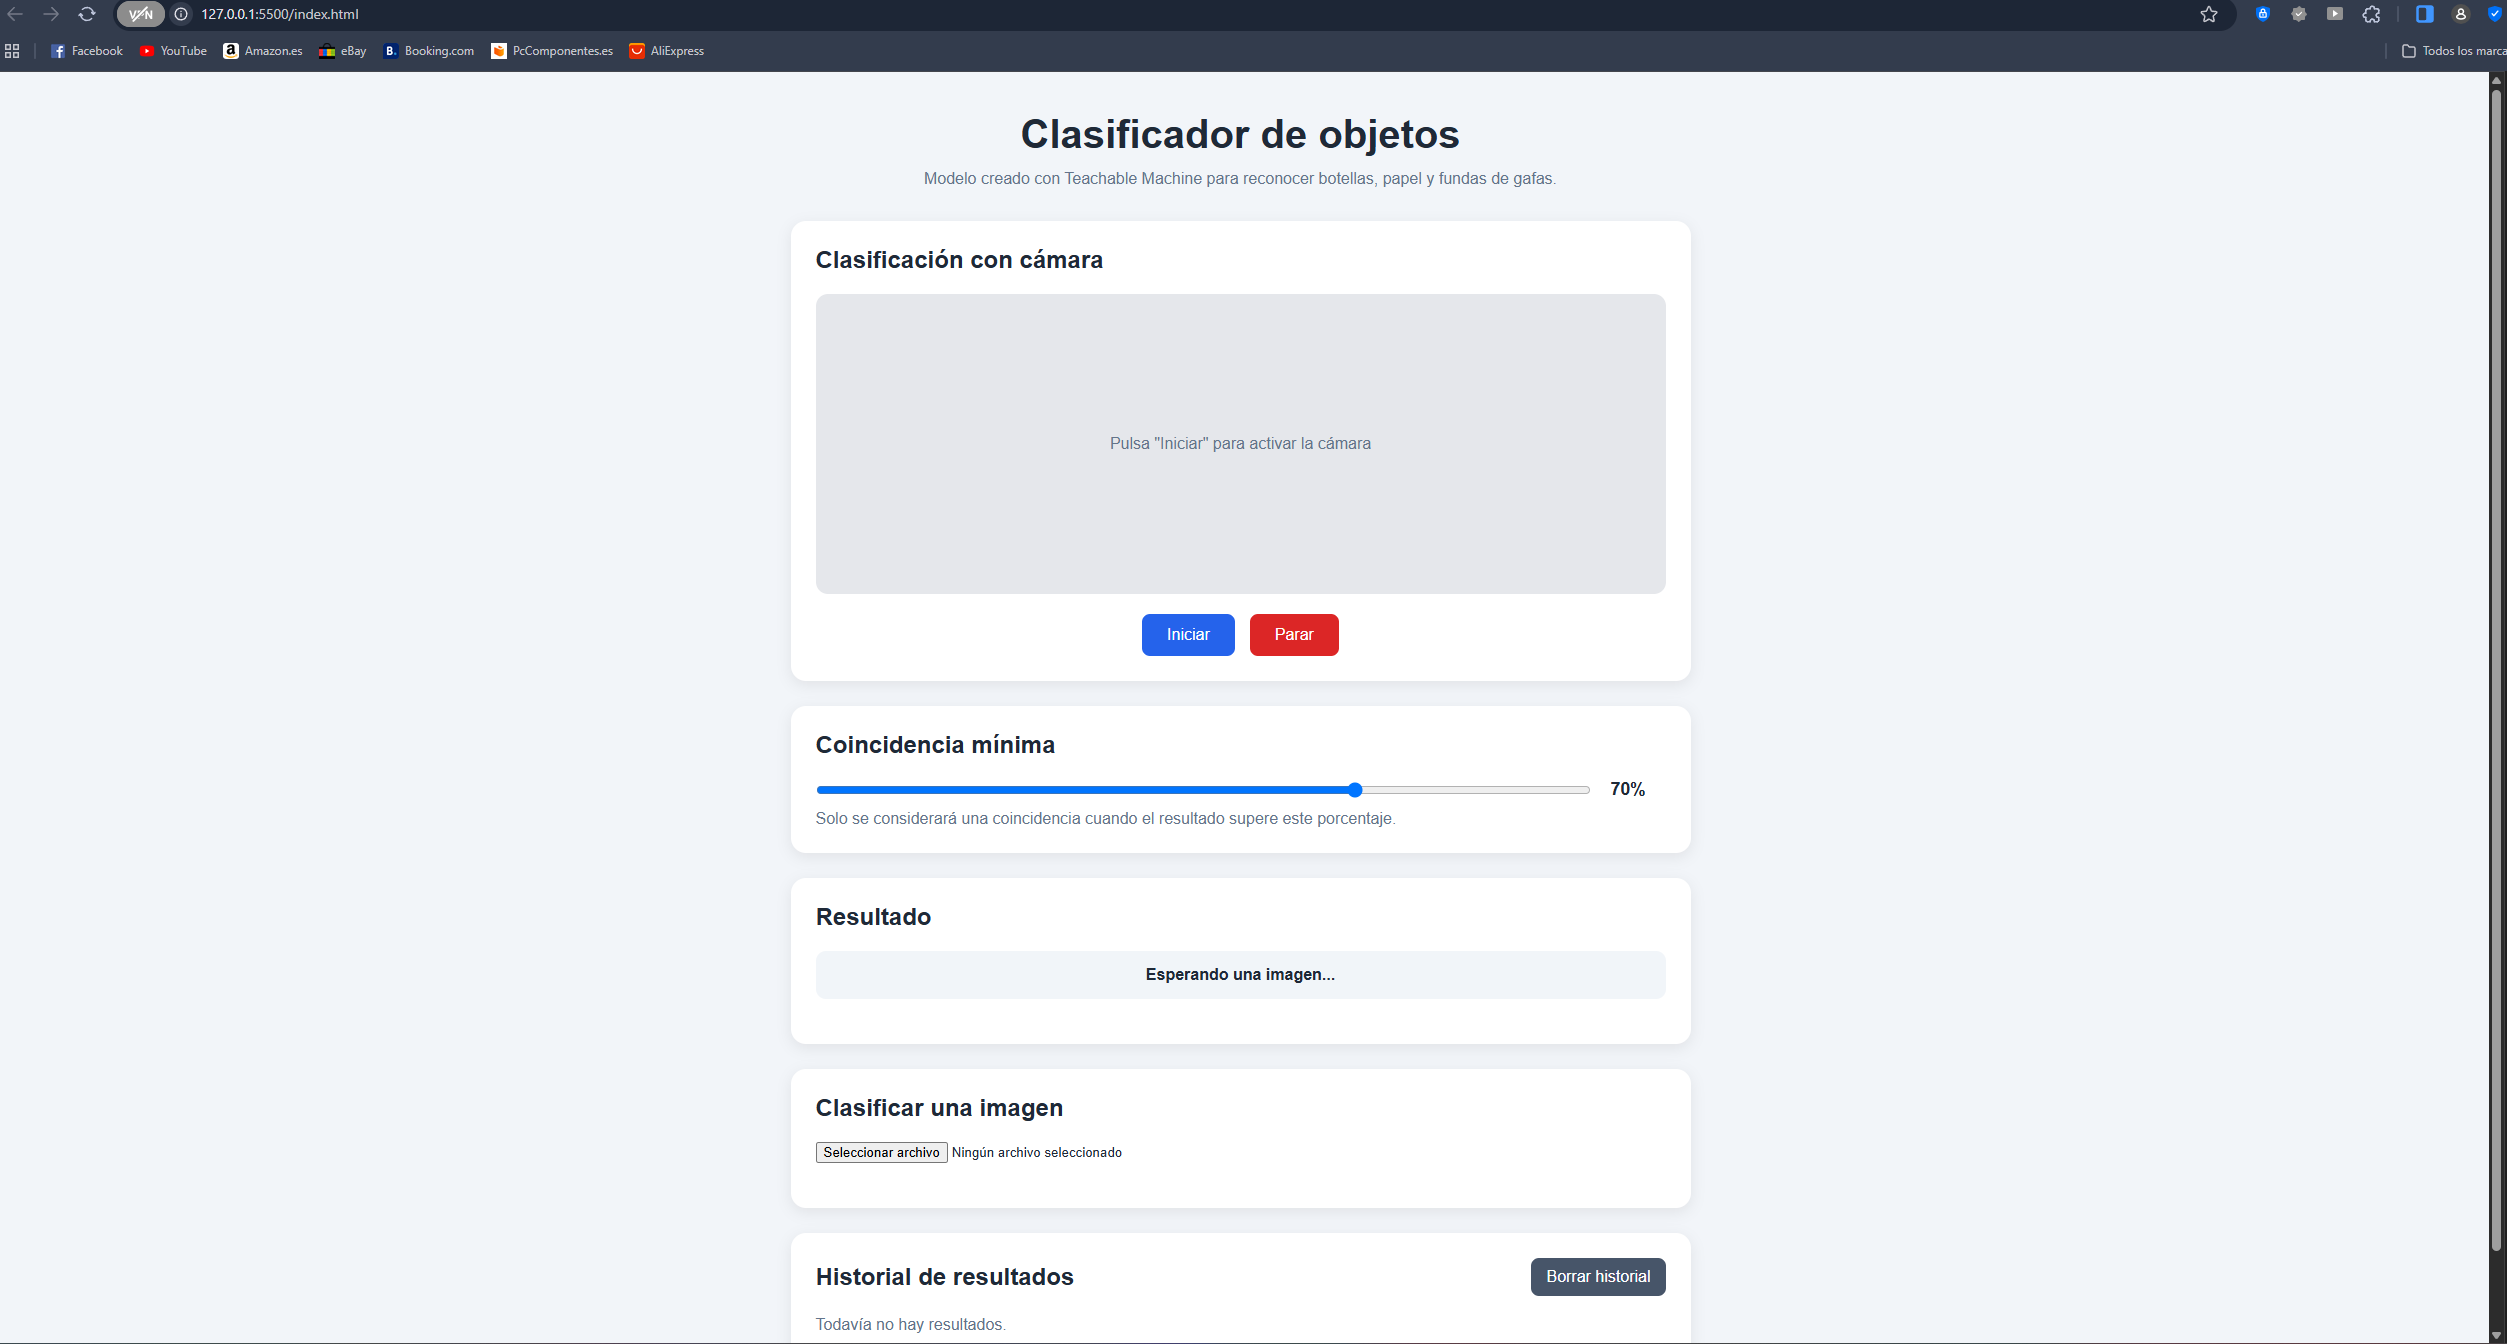

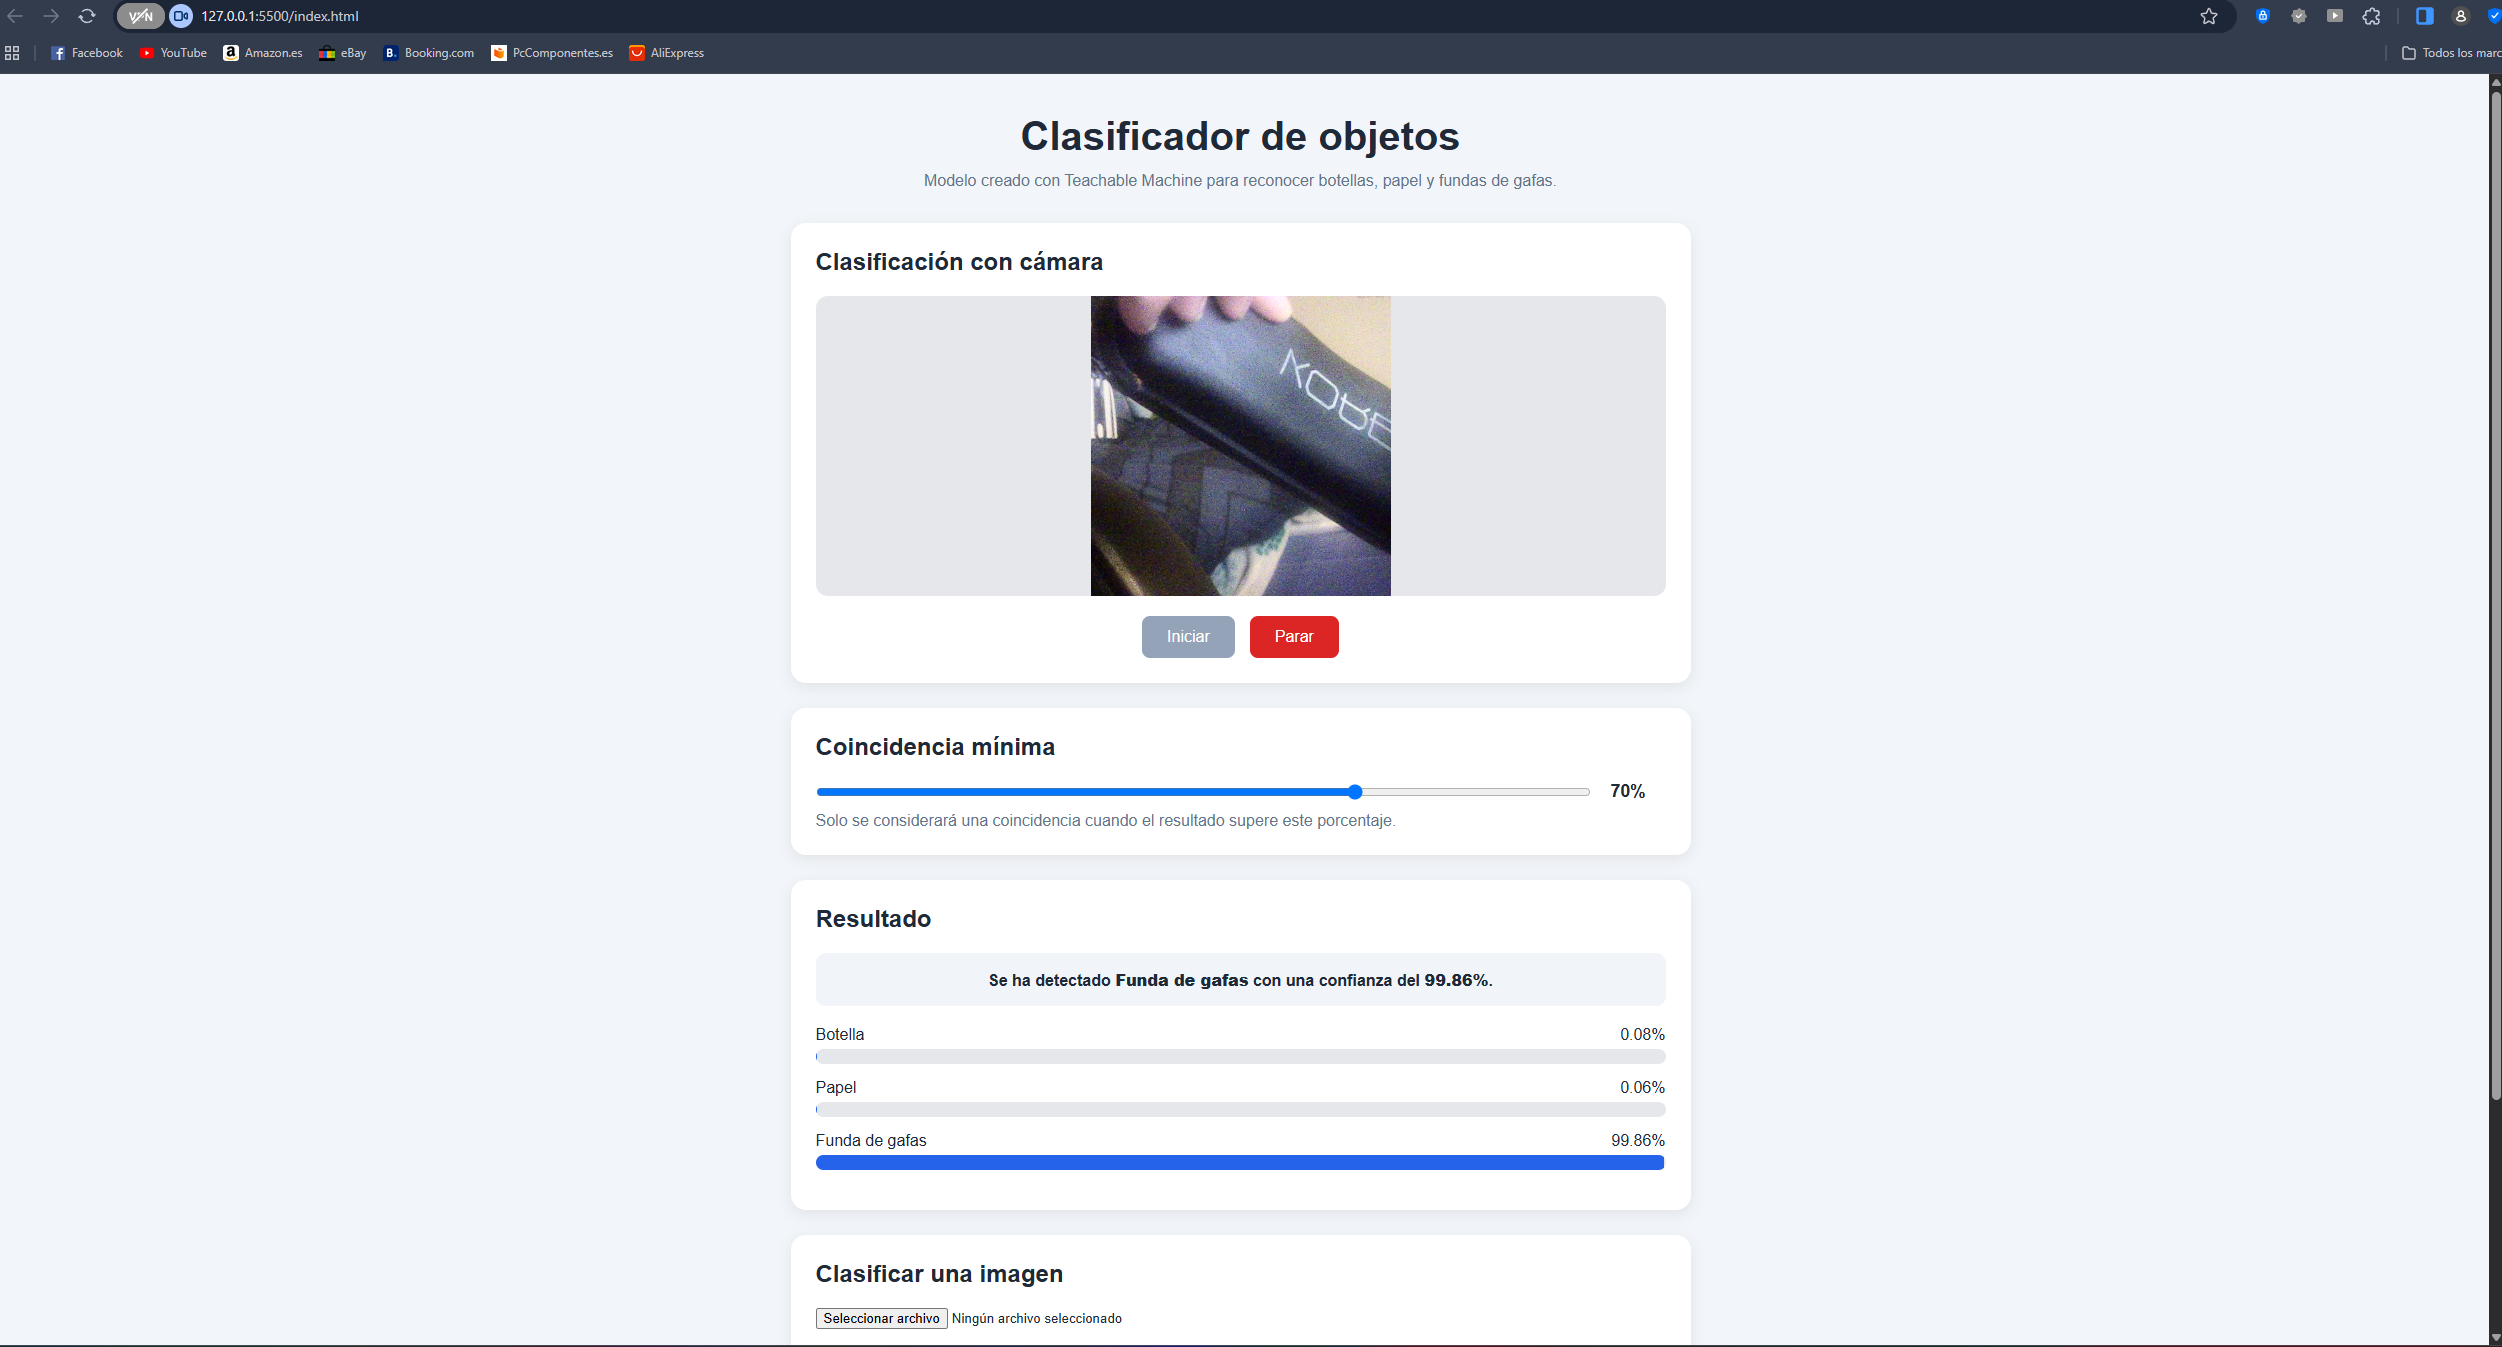